# Clusterização / Segmentação de Clientes — PRT Seguros

Este notebook realiza a segmentação de clientes via K-Means e cruza os clusters com o histórico de churn, conforme proposta do projeto.

**Fluxo geral:**
1. Carregar e selecionar variáveis
2. Tratar multicolinearidade e nulos
3. Padronizar features
4. Escolher o número de clusters (Cotovelo + Silhueta)
5. Treinar o K-Means final
6. Cruzar clusters × churn e gerar o perfil de cada segmento
7. Visualizar os clusters em 2D via PCA

## 1. Imports e configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"

RANDOM_STATE = 42

## 2. Carregar dados

Ajuste o caminho abaixo para apontar para a base unificada tratada do projeto.

In [2]:
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Tratada.csv")
print(df.shape)
df.head()

(81881, 84)


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,...,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,churned,num_apolices_premium,num_apolices_basica,num_apolices_padrao
0,221300904264,2.0,2316.72,2339.0,01/05/2020,5.0,201525.43,2446.83,1.0,0.066,...,0,0,0,0,0,0,0,2.0,0.0,0.0
1,221300318278,3.0,NaN,1648.0,26/11/2021,1.0,NaN,NaN,1.0,0.103,...,0,1,0,0,0,0,0,0.0,3.0,0.0
2,221302854940,NaN,1033.15,187.0,26/11/2025,5.0,196256.43,951.09,1.0,0.050,...,0,0,0,0,0,0,0,NaN,NaN,NaN
3,221300164895,1.0,873.83,1085.0,12/06/2023,4.0,150726.78,840.06,1.0,0.034,...,0,0,0,0,0,0,0,1.0,0.0,0.0
4,221302543275,1.0,1084.81,5315.0,12/11/2011,4.0,208885.94,1109.27,1.0,0.018,...,0,0,0,0,0,1,0,0.0,1.0,0.0


## 3. Selecionar variáveis para a clusterização

> **Importante:** a coluna `churned` **não entra** como feature do K-Means.  
> Ela é mantida no dataframe e cruzada **depois** da clusterização para revelar o perfil de risco de cada segmento.

Features selecionadas pela **correlação absoluta com `churned`** (calculada na análise exploratória).  
Threshold mínimo: |corr| > 0.01. Excluídas: `renovacoes_consecutivas` (multicolinearidade 0.94 com `tempo_cliente_dias`).

| # | Feature | Correlação | Direção |
|---|---|---|---|
| 1 | `tempo_cliente_dias` | **0.298** | cliente antigo → menos churn |
| 2 | `num_apolices_ativas` | **0.252** | mais apólices → mais churn |
| 3 | `num_produtos_contratados` | **0.243** | mais produtos → menos churn |
| 4 | `desconto_aplicado_pct` | **0.235** | desconto alto → mais churn |
| 5 | `indice_relacionamento` | **0.191** | relacionamento alto → menos churn |
| 6 | `num_apolices_basica` | **0.175** | apólices básicas → mais churn |
| 7 | `satisfacao_nps` | **0.165** | satisfação alta → menos churn |
| 8 | `tipo_cobertura_basica` | **0.155** | cobertura básica → mais churn |
| 9 | `estado_civil` | **0.144** | solteiro → mais churn |
| 10 | `tipo_cobertura_premium` | **0.143** | cobertura premium → menos churn |
| 11 | `tem_filhos` | **0.118** | tem filhos → menos churn |
| 12 | `renda_anual` | **0.102** | renda alta → menos churn |
| 13 | `qtd_dependentes` | **0.100** | mais dependentes → menos churn |
| 14 | `valor_imovel` | **0.098** | imóvel caro → menos churn |
| 15 | `num_apolices_premium` | **0.078** | apólices premium → menos churn |
| 16 | `valor_cobertura_total` | **0.070** | cobertura alta → menos churn |
| 17 | `idade` | **0.063** | mais velho → menos churn |
| 18 | `num_apolices_padrao` | **0.059** | apólices padrão → mais churn |
| 19 | `score_engajamento_digital` | **0.051** | engajamento digital → mais churn |
| 20 | `pagamento_em_dia` | **0.049** | paga em dia → menos churn |
| 21 | `num_reclamacoes_12m` | **0.043** | reclamações → mais churn |
| 22 | `num_acessos_app_mes` | **0.036** | acessa app → mais churn |
| 23 | `possui_imovel` | **0.022** | tem imóvel → menos churn |
| 24 | `tipo_cobertura_padrao` | **0.021** | cobertura padrão → menos churn |
| 25 | `valor_premio_anual` | 0.013 | — |
| 26 | `franquia_media` | 0.011 | — |

In [3]:
features_cluster = [
    # |corr| > 0.10 — impacto forte
    "tempo_cliente_dias",         # 0.298 — top 1
    "num_apolices_ativas",        # 0.252 — top 2
    "num_produtos_contratados",   # 0.243 — top 3
    "desconto_aplicado_pct",      # 0.235 — top 4
    "indice_relacionamento",      # 0.191 — top 5
    "num_apolices_basica",        # 0.175 — top 6
    "satisfacao_nps",             # 0.165 — top 7
    "tipo_cobertura_basica",      # 0.155 — top 8
    "estado_civil",               # 0.144 — top 9
    "tipo_cobertura_premium",     # 0.143 — top 10
    "tem_filhos",                 # 0.118 — top 11
    "renda_anual",                # 0.102 — top 12
    "qtd_dependentes",            # 0.100 — top 13
    "valor_imovel",               # 0.098 — top 14

    # |corr| 0.02–0.10 — impacto moderado
    "num_apolices_premium",       # 0.078
    "valor_cobertura_total",      # 0.070
    "idade",                      # 0.063
    "num_apolices_padrao",        # 0.059
    "score_engajamento_digital",  # 0.051
    "pagamento_em_dia",           # 0.049
    "num_reclamacoes_12m",        # 0.043
    "num_acessos_app_mes",        # 0.036
    "possui_imovel",              # 0.022
    "tipo_cobertura_padrao",      # 0.021

    # |corr| 0.01–0.02 — impacto fraco mas presente
    "valor_premio_anual",         # 0.013
    "franquia_media",             # 0.011
]

X_cluster = df[features_cluster].copy()
print(f"Total de features: {len(features_cluster)}")
print(f"Shape: {X_cluster.shape}")
X_cluster.describe()

Total de features: 26
Shape: (81881, 26)


,tempo_cliente_dias,num_apolices_ativas,num_produtos_contratados,desconto_aplicado_pct,indice_relacionamento,num_apolices_basica,satisfacao_nps,tipo_cobertura_basica,estado_civil,tipo_cobertura_premium,...,idade,num_apolices_padrao,score_engajamento_digital,pagamento_em_dia,num_reclamacoes_12m,num_acessos_app_mes,possui_imovel,tipo_cobertura_padrao,valor_premio_anual,franquia_media
count,81877.000000,77726.000000,77850.000000,77832.000000,81881.000000,77726.000000,81881.000000,81881.000000,77805.000000,81881.000000,...,81881.000000,77726.000000,81881.000000,77812.000000,81881.000000,81881.00000,77722.000000,81881.000000,77395.000000,77864.000000
mean,2367.276463,2.417454,2.339281,0.096686,54.154655,1.025899,6.237186,0.321088,0.432003,0.271235,...,43.690551,0.870108,51.170894,0.935498,0.871875,10.24168,0.992718,0.358874,1305.190947,1004.216649
std,1528.210420,1.266273,1.531749,0.054291,17.086414,1.603249,2.226698,0.466897,0.495358,0.444600,...,12.343017,1.375298,19.496528,0.245646,0.824980,4.77199,0.085026,0.479673,485.286270,391.545380
min,30.000000,1.000000,1.000000,0.000000,6.050000,0.000000,0.500000,0.000000,0.000000,0.000000,...,18.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,365.270000,188.090000
25%,1193.000000,1.000000,1.000000,0.051000,43.000000,0.000000,5.000000,0.000000,0.000000,0.000000,...,35.000000,0.000000,38.000000,1.000000,0.000000,7.00000,1.000000,0.000000,1068.955000,706.497500
50%,2236.000000,2.000000,2.000000,0.091000,54.400000,0.000000,6.000000,0.000000,0.000000,0.000000,...,44.000000,0.000000,51.000000,1.000000,1.000000,10.00000,1.000000,0.000000,1226.620000,960.940000
75%,3395.000000,4.000000,4.000000,0.141000,65.700000,2.000000,8.000000,1.000000,1.000000,1.000000,...,52.000000,2.000000,64.000000,1.000000,1.000000,13.00000,1.000000,1.000000,1417.860000,1239.852500
max,8000.000000,6.000000,7.000000,0.250000,100.000000,6.000000,12.500000,1.000000,1.000000,1.000000,...,95.000000,6.000000,100.000000,1.000000,2.500000,24.50000,1.000000,1.000000,9126.690000,4341.720000


## 4. Multicolinearidade: `tempo_cliente_dias` × `renovacoes_consecutivas`

A EDA revelou correlação ~0,94 entre essas duas variáveis. Incluir ambas distorceria o cálculo de distância euclidiana do K-Means (peso duplicado na mesma dimensão). Por isso, `renovacoes_consecutivas` foi excluída da lista acima.

Descomente a linha abaixo para confirmar a correlação neste dataset:

In [4]:
# print(df[["tempo_cliente_dias", "renovacoes_consecutivas"]].corr())

## 5. Tratar valores nulos

Imputação pela mediana — mesma lógica da modelagem de churn: nunca sobrescrever os dados originais, trabalhar sempre em cópia.

In [5]:
from sklearn.impute import SimpleImputer

print("Nulos por coluna:")
print(X_cluster.isnull().sum())

imputer = SimpleImputer(strategy="median")
X_cluster_model = X_cluster.copy()
X_cluster_model[:] = imputer.fit_transform(X_cluster_model)

assert X_cluster_model.isnull().sum().sum() == 0
print("OK — sem nulos em X_cluster_model")

Nulos por coluna:
tempo_cliente_dias              4
num_apolices_ativas          4155
num_produtos_contratados     4031
desconto_aplicado_pct        4049
indice_relacionamento           0
num_apolices_basica          4155
satisfacao_nps                  0
tipo_cobertura_basica           0
estado_civil                 4076
tipo_cobertura_premium          0
tem_filhos                   4151
renda_anual                  4295
qtd_dependentes              4014
valor_imovel                 4868
num_apolices_premium         4155
valor_cobertura_total        4301
idade                           0
num_apolices_padrao          4155
score_engajamento_digital       0
pagamento_em_dia             4069
num_reclamacoes_12m             0
num_acessos_app_mes             0
possui_imovel                4159
tipo_cobertura_padrao           0
valor_premio_anual           4486
franquia_media               4017
dtype: int64
OK — sem nulos em X_cluster_model


## 6. Padronizar as variáveis (obrigatório para K-Means)

Sem padronização, variáveis em escalas maiores (ex.: `valor_cobertura_total` na casa de centenas de mil reais) dominariam o cálculo de distância sobre variáveis em escalas menores (ex.: `satisfacao_nps`, de 0 a 10).

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_model)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_cluster_model.columns)
X_scaled_df.describe()

,tempo_cliente_dias,num_apolices_ativas,num_produtos_contratados,desconto_aplicado_pct,indice_relacionamento,num_apolices_basica,satisfacao_nps,tipo_cobertura_basica,estado_civil,tipo_cobertura_premium,...,idade,num_apolices_padrao,score_engajamento_digital,pagamento_em_dia,num_reclamacoes_12m,num_acessos_app_mes,possui_imovel,tipo_cobertura_padrao,valor_premio_anual,franquia_media
count,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,...,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04,8.188100e+04
mean,-2.776880e-17,-1.221827e-16,9.024859e-18,4.165319e-17,3.222916e-16,-8.052951e-17,1.072570e-16,6.942199e-17,-3.540521e-17,-7.228565e-17,...,-6.976910e-17,-6.005002e-17,-8.521549e-17,5.171938e-17,5.380204e-18,2.169437e-17,4.567967e-16,-6.942199e-18,3.924078e-16,1.551581e-16
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,...,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-1.529463e+00,-1.128650e+00,-8.844532e-01,-1.820819e+00,-2.815392e+00,-6.170670e-01,-2.576560e+00,-6.877098e-01,-8.344744e-01,-6.100693e-01,...,-2.081396e+00,-6.102448e-01,-2.624632e+00,-3.913337e+00,-1.056851e+00,-2.146221e+00,-1.198608e+01,-7.481691e-01,-1.981646e+00,-2.131278e+00
25%,-7.684188e-01,-1.128650e+00,-8.844532e-01,-8.197925e-01,-6.528417e-01,-6.170670e-01,-5.556179e-01,-6.877098e-01,-8.344744e-01,-6.100693e-01,...,-7.040908e-01,-6.102448e-01,-6.755549e-01,2.555364e-01,-1.056851e+00,-6.793183e-01,8.343012e-02,-7.481691e-01,-4.706354e-01,-7.389102e-01
50%,-8.590050e-02,-3.203178e-01,-2.157189e-01,-1.020751e-01,1.435916e-02,-6.170670e-01,-1.065197e-01,-6.877098e-01,-8.344744e-01,-6.100693e-01,...,2.507093e-02,-6.102448e-01,-8.765427e-03,2.555364e-01,1.553077e-01,-5.064585e-02,8.343012e-02,-7.481691e-01,-1.572969e-01,-1.077509e-01
75%,6.725259e-01,4.880140e-01,1.121750e+00,7.856280e-01,6.757073e-01,6.502191e-01,7.916768e-01,1.454102e+00,1.198359e+00,1.639158e+00,...,6.732147e-01,1.285908e-01,6.580240e-01,2.555364e-01,1.553077e-01,5.780266e-01,8.343012e-02,1.336596e+00,2.180148e-01,5.791774e-01
max,3.685946e+00,2.913009e+00,3.127953e+00,2.901006e+00,2.683162e+00,3.184791e+00,2.812619e+00,1.454102e+00,1.198359e+00,1.639158e+00,...,4.156987e+00,3.822769e+00,2.504518e+00,2.555364e-01,1.973545e+00,2.987938e+00,8.343012e-02,1.336596e+00,1.657514e+01,8.744031e+00


## 7. Método do Cotovelo — escolher o k ideal

Roda o K-Means para k = 2…10 e mede a **inércia** (soma das distâncias de cada ponto ao centroide do seu cluster).  
Procuramos o ponto onde a curva para de cair de forma acentuada — o "cotovelo".

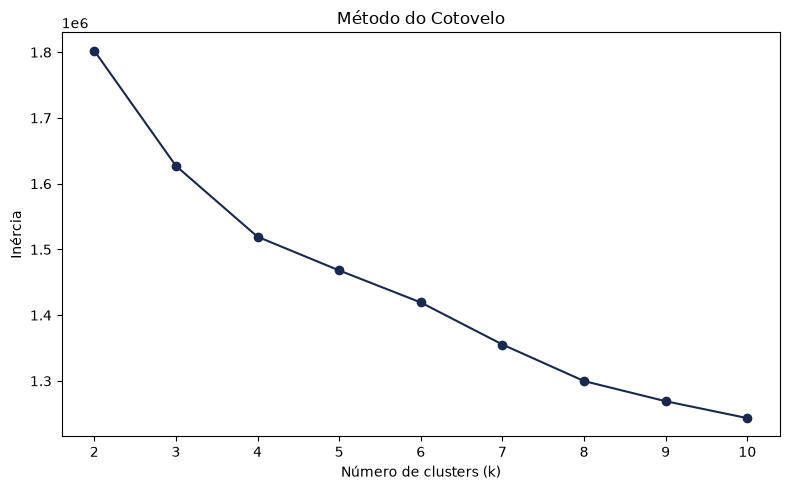

In [7]:
inercias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inercias, marker="o", color=PRT_NAVY)
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inércia")
ax.set_title("Método do Cotovelo")
plt.tight_layout()
plt.show()

## 8. Método da Silhueta — complemento ao cotovelo

Mede o quão bem separados e coesos estão os clusters.  
Varia de **-1** a **1** — quanto maior, melhor a separação entre grupos.

> **Nota de performance:** `silhouette_score` é O(n²) — inviável para ~82 mil linhas. O cálculo é feito em uma **amostra aleatória de 30.000 pontos** (~37% do dataset), o que dá uma estimativa muito precisa em ~1-2 minutos.

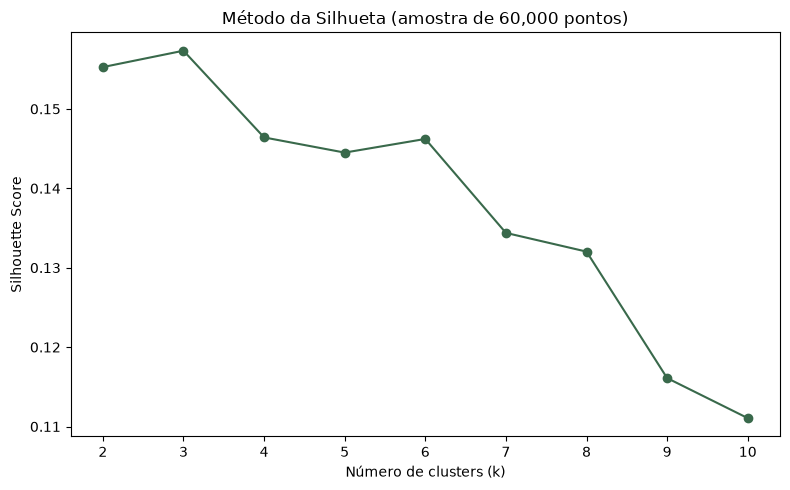

{2: 0.1553, 3: 0.1573, 4: 0.1464, 5: 0.1445, 6: 0.1462, 7: 0.1344, 8: 0.132, 9: 0.1161, 10: 0.1111}


In [8]:
SILHOUETTE_SAMPLE = 60_000
rng = np.random.default_rng(RANDOM_STATE)

silhuetas = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)

    idx   = rng.choice(len(X_scaled), size=SILHOUETTE_SAMPLE, replace=False)
    score = silhouette_score(X_scaled[idx], labels[idx])
    silhuetas.append(score)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, silhuetas, marker="o", color=PRT_GREEN)
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title(f"Método da Silhueta (amostra de {SILHOUETTE_SAMPLE:,} pontos)")
plt.tight_layout()
plt.show()

print(dict(zip(k_range, [round(s, 4) for s in silhuetas])))

## 9. Treinar o K-Means final

Ajuste `K_FINAL` com base no que você observou nas células 7 e 8.  
O ponto de cotovelo e o k com maior silhueta nem sempre coincidem — use também o bom senso de negócio (menos clusters = mais fácil de agir).

In [9]:
K_FINAL = 4  # AJUSTE conforme a análise das células 7 e 8

kmeans_final   = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster"]  = kmeans_final.fit_predict(X_scaled)

print(df["cluster"].value_counts().sort_index())

cluster
0    22160
1    22069
2    25172
3    12480
Name: count, dtype: int64


## 10. Clusters × Taxa de churn

Análise central da proposta: qual segmento concentra maior risco de cancelamento.

         taxa_churn  n_clientes  taxa_churn_pct
cluster                                        
2          0.217186       25172            21.7
3          0.213702       12480            21.4
0          0.044088       22160             4.4
1          0.036114       22069             3.6


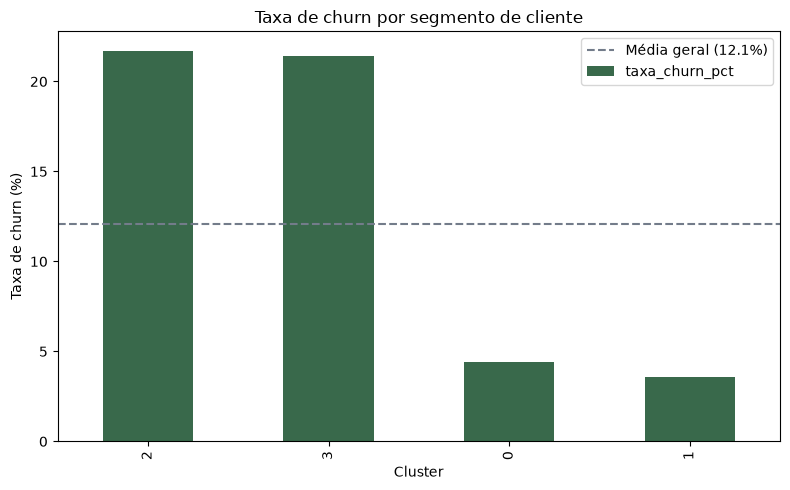

In [10]:
churn_por_cluster = df.groupby("cluster")["churned"].agg(["mean", "count"])
churn_por_cluster.columns = ["taxa_churn", "n_clientes"]
churn_por_cluster["taxa_churn_pct"] = (churn_por_cluster["taxa_churn"] * 100).round(1)

print(churn_por_cluster.sort_values("taxa_churn", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
churn_por_cluster["taxa_churn_pct"].sort_values(ascending=False).plot(
    kind="bar", ax=ax, color=PRT_GREEN
)
ax.axhline(
    y=df["churned"].mean() * 100,
    color=PRT_GRAY, linestyle="--",
    label=f"Média geral ({df['churned'].mean()*100:.1f}%)"
)
ax.set_xlabel("Cluster")
ax.set_ylabel("Taxa de churn (%)")
ax.set_title("Taxa de churn por segmento de cliente")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Perfil de cada cluster

Médias das variáveis originais por segmento — a "ficha de personagem" de cada grupo para apresentação ao time de negócio.

In [11]:
perfil_clusters = df.groupby("cluster")[features_cluster].mean().round(2)
perfil_clusters["n_clientes"]    = df["cluster"].value_counts().sort_index()
perfil_clusters["taxa_churn_pct"] = churn_por_cluster["taxa_churn_pct"]

print(perfil_clusters)

         tempo_cliente_dias  num_apolices_ativas  num_produtos_contratados  \
cluster                                                                      
0                   3167.79                 1.49                      3.58   
1                   3078.20                 1.50                      3.13   
2                   1517.22                 3.43                      1.15   
3                   1403.08                 3.60                      1.13   

         desconto_aplicado_pct  indice_relacionamento  num_apolices_basica  \
cluster                                                                      
0                         0.06                  56.90                 0.00   
1                         0.06                  56.87                 0.16   
2                         0.14                  50.97                 3.19   
3                         0.14                  50.91                 0.00   

         satisfacao_nps  tipo_cobertura_basica  estado_civil  

## 12. Visualização 2D dos clusters via PCA

O K-Means opera em N dimensões (uma por feature) — impossível de plotar diretamente.  
O PCA reduz para 2 componentes artificiais que preservam o máximo de variância possível, **apenas para fins de visualização**.

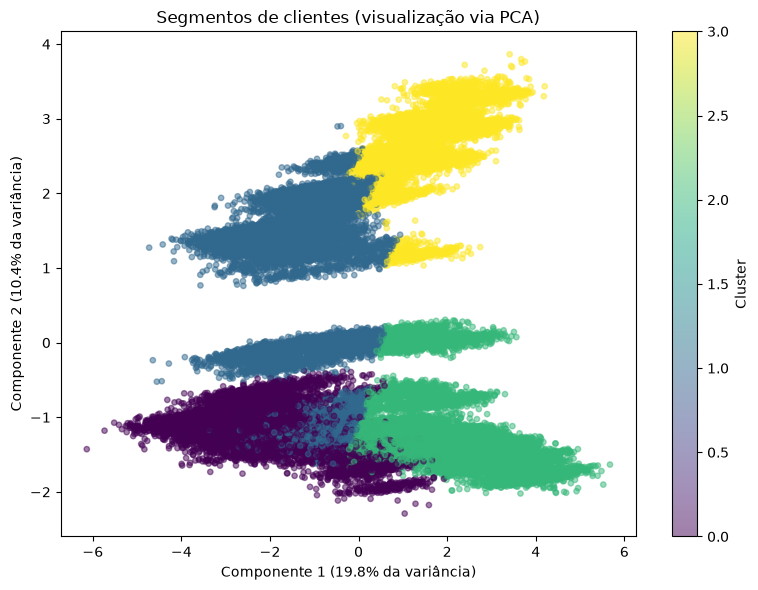

In [12]:
pca        = PCA(n_components=2, random_state=RANDOM_STATE)
coords_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    coords_pca[:, 0], coords_pca[:, 1],
    c=df["cluster"], cmap="viridis", alpha=0.5, s=15
)
ax.set_xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)")
ax.set_ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)")
ax.set_title("Segmentos de clientes (visualização via PCA)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()